# STEP 1. 통계 검정

In [5]:
import pandas as pd
df = pd.read_csv("data/advertising.csv")

In [19]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,NaN,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,3/27/2016 0:53,0
1,80.23,31.0,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,4/4/2016 1:39,0
2,69.47,26.0,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,3/13/2016 20:35,0
3,74.15,29.0,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,1/10/2016 2:31,0
4,68.37,35.0,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,6/3/2016 3:36,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       916 non-null    float64
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 78.3+ KB


In [20]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,916.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.128821,55000.000080,180.000100,0.481000,0.50000
std,15.853615,9.018548,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


### 성별과 구매 여부

In [ ]:
# 귀무가설 : 성별과 광고 클릭 여부는 독립이다.
# 대립가설 : 설별과 광고 클릭 여부는 독립이 아니다.

In [16]:
# 교차 표 생성
ct = pd.crosstab(df['Male'], df['Clicked on Ad'])
ct

Clicked on Ad,0,1
Male,,
0,250,269
1,250,231


In [25]:
# 카이제곱 검정
from scipy.stats import chi2_contingency

chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(1.2978741302440726), pvalue=np.float64(0.2546019035670961), dof=1, expected_freq=array([[259.5, 259.5],
       [240.5, 240.5]]))

In [ ]:
# p-value : 0.2346
# 귀무가설 채택 : 성별과 클릭텨부 사이에 유의미한 관계가 없다.

### 체류시간에 따른 구매 차이 → t-test

In [29]:
buyer = df[df["Clicked on Ad"]== 1]["Daily Time Spent on Site"]
non_buyer = df[df["Clicked on Ad"]== 0]["Daily Time Spent on Site"]

# 평균확인
print("구매 평균:", buyer.mean())
print("비구매 평균:", non_buyer.mean())

구매 평균: 53.14578
비구매 평균: 76.85462


In [32]:
# t-test
from scipy.stats import ttest_ind

t_stat, p = ttest_ind(buyer, non_buyer)
print("값:", t_stat)
print("p값:", p)

값: -35.61636085995531
p값: 5.877384244135832e-180


In [ ]:
# p < 0.05
# 대립가설 : 체류시간에 따른 유의미한 구매 차이가 있다.
# 클릭한 사람들의 평균 체류시간이 클릭하지 않은 사람들보다 짧다.

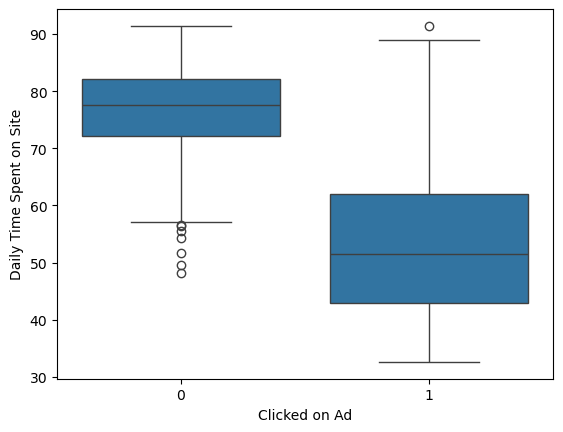

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Clicked on Ad",
            y="Daily Time Spent on Site",
            data=df);

# STEP 2. 전처리

### OneHotEncoding

In [37]:
# 범주형 변수 다중공선성 방지
categorical_cols = ["City", "Country"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

### 이상치 처리

In [87]:
# 연속형 변수 : Daily Time Spent on Site, Age, Area Income, Daily Internet Usage

cols_list = ["Daily Time Spent on Site",
            "Age",
            "Area Income",
            "Daily Internet Usage"]

import numpy as np

Q1 = df[cols_list].quantile(0.25)
Q3 = df[cols_list].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_filtered = df[~((df[cols_list] < lower_bound) | (df[cols_list] > upper_bound)).any(axis=1)]

Daily Time Spent on Site       51.1475
Age                            29.0000
Area Income                 47352.7775
Daily Internet Usage          138.8300
Name: 0.25, dtype: float64 Daily Time Spent on Site       78.3800
Age                            42.0000
Area Income                 65497.5675
Daily Internet Usage          218.6550
Name: 0.75, dtype: float64 Daily Time Spent on Site       27.2325
Age                            13.0000
Area Income                 18144.7900
Daily Internet Usage           79.8250
dtype: float64


### Class imbalance 확인

In [67]:
df["Clicked on Ad"].value_counts(normalize=True)

Clicked on Ad
0    0.5
1    0.5
Name: proportion, dtype: float64

# STEP 3.모델링

In [75]:
from sklearn.model_selection import train_test_split

X = df[ ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male'] ]
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# 데이터가 잘 분리되었는지 확인
print(X_train.shape) # X_train: 80
print(X_test.shape)  # X_test : 20
print(y_train.shape)
print(y_test.shape)

(726, 5)
(182, 5)
(726,)
(182,)


In [83]:
# 모델 불러오기
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [91]:
# 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
# 모델학습
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [98]:
# 예측
y_pred = model.predict(X_test)
y_pred

array([1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1])

In [99]:
# 분류 리포드
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[92  0]
 [ 4 86]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        92
           1       1.00      0.96      0.98        90

    accuracy                           0.98       182
   macro avg       0.98      0.98      0.98       182
weighted avg       0.98      0.98      0.98       182

